Transfer Learning :
It is a Deep Learning technique where we use a pre-trained model.This pre-trained model is trained for one task and can be re-trained for a similar task with smaller dataset.

When you train a model from Scratch but on smaller dataset you will not achieve high accuracy thus we here using Transfer learning

Transfer Learning gives higher accuracy compared to training models from scratch.

Ex. if you trained a model on image recognisation of face mask but you can use this for dog cat classification too

Examples of Pre-Trained Models(used for image detection):


*   VGG-16
*   ResNet50
*   Inceptionv3
*   MobileNet V2 (light weight)

Workflow :      
Dataset --> Image Preprocessing --> Train Test Split --> Pretrained MobileNet Model

New Image --> MobileNet model trained on dog vs cat data --> Output



# Importing Dataset

In [1]:
#install the kaggle library
!pip install kaggle

In [2]:
#configure the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Dog vs Cat Dataset from Kaggle

In [3]:
#Kaggle API
!kaggle competitions download -c dogs-vs-cats

 96% 783M/812M [00:04<00:00, 210MB/s]
100% 812M/812M [00:04<00:00, 182MB/s]


In [4]:
#extracting the compressed files
from zipfile import ZipFile
dataset = "dogs-vs-cats.zip"

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("The Dataset is Extracted")

The Dataset is Extracted


In [6]:
#extracting the compressed files
from zipfile import ZipFile
dataset1 = "/content/train.zip"
dataset2 = "/content/test1.zip"

with ZipFile(dataset1, 'r') as zip:
  zip.extractall()
  print("The Dataset1 is Extracted")

with ZipFile(dataset2, 'r') as zip:
  zip.extractall()
  print("The Dataset2 is Extracted")

The Dataset1 is Extracted
The Dataset2 is Extracted


In [7]:
import os

#counting the number of files in train folder

path , dirs, files1 = next(os.walk("/content/train"))
file_count = len(files1)
print('Number of Images : ', file_count)

path , dirs, files2 = next(os.walk("/content/test1"))
file_count = len(files2)
print('Number of Images : ', file_count)


Number of Images :  25000
Number of Images :  12500


Printing the names of images

In [8]:
file_names = os.listdir("/content/train")
print(file_names)

['dog.4039.jpg', 'dog.4858.jpg', 'cat.18.jpg', 'cat.3843.jpg', 'dog.11862.jpg', 'cat.2885.jpg', 'cat.11375.jpg', 'dog.12103.jpg', 'cat.376.jpg', 'cat.5177.jpg', 'cat.10299.jpg', 'dog.4227.jpg', 'cat.37.jpg', 'dog.4072.jpg', 'dog.8837.jpg', 'dog.7863.jpg', 'dog.11435.jpg', 'cat.10067.jpg', 'dog.3694.jpg', 'cat.8296.jpg', 'dog.5032.jpg', 'cat.6242.jpg', 'dog.907.jpg', 'cat.8596.jpg', 'cat.1538.jpg', 'cat.4291.jpg', 'cat.1847.jpg', 'dog.3923.jpg', 'dog.12181.jpg', 'dog.4062.jpg', 'dog.4759.jpg', 'dog.10723.jpg', 'cat.9215.jpg', 'dog.5789.jpg', 'dog.3154.jpg', 'dog.10748.jpg', 'dog.1631.jpg', 'cat.1315.jpg', 'dog.2125.jpg', 'cat.1042.jpg', 'cat.8147.jpg', 'dog.39.jpg', 'cat.4095.jpg', 'cat.1716.jpg', 'dog.1421.jpg', 'dog.9925.jpg', 'cat.6629.jpg', 'cat.1251.jpg', 'dog.2312.jpg', 'dog.5591.jpg', 'cat.9313.jpg', 'dog.9910.jpg', 'dog.1256.jpg', 'cat.11631.jpg', 'cat.10088.jpg', 'dog.6993.jpg', 'cat.6761.jpg', 'dog.5728.jpg', 'dog.1063.jpg', 'dog.7199.jpg', 'dog.9744.jpg', 'dog.5066.jpg', 'dog

In [9]:
import os

os.makedirs("/content/train/cats", exist_ok=True)
os.makedirs("/content/train/dogs", exist_ok=True)


In [10]:
import shutil

src_folder = "/content/train"
for file_name in os.listdir(src_folder):
    if file_name.startswith("cat"):
        shutil.move(os.path.join(src_folder, file_name), os.path.join(src_folder, "cats", file_name))
    elif file_name.startswith("dog"):
        shutil.move(os.path.join(src_folder, file_name), os.path.join(src_folder, "dogs", file_name))


Error: Cannot move a directory '/content/train/cats' into itself '/content/train/cats/cats'.

In [11]:
import os
import shutil

src_folder = "/content/train"
cat_folder = os.path.join(src_folder, "cats")
dog_folder = os.path.join(src_folder, "dogs")

# Create target folders
os.makedirs(cat_folder, exist_ok=True)
os.makedirs(dog_folder, exist_ok=True)

# Move only files (not folders) to the right class subfolder
for file_name in os.listdir(src_folder):
    file_path = os.path.join(src_folder, file_name)

    # Skip folders
    if os.path.isdir(file_path):
        continue

    if file_name.startswith("cat"):
        shutil.move(file_path, os.path.join(cat_folder, file_name))
    elif file_name.startswith("dog"):
        shutil.move(file_path, os.path.join(dog_folder, file_name))


In [12]:
import os
import shutil

src_folder = "/content/test1"
cat_folder = os.path.join(src_folder, "cats")
dog_folder = os.path.join(src_folder, "dogs")

# Create target folders
os.makedirs(cat_folder, exist_ok=True)
os.makedirs(dog_folder, exist_ok=True)

# Move only files (not folders) to the right class subfolder
for file_name in os.listdir(src_folder):
    file_path = os.path.join(src_folder, file_name)

    # Skip folders
    if os.path.isdir(file_path):
        continue

    if file_name.startswith("cat"):
        shutil.move(file_path, os.path.join(cat_folder, file_name))
    elif file_name.startswith("dog"):
        shutil.move(file_path, os.path.join(dog_folder, file_name))


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,  # 80% train, 20% val
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


In [17]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt


In [18]:
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False  # Freeze base layers

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [20]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 334s 513ms/step - accuracy: 0.9079 - loss: 0.2197 - val_accuracy: 0.9766 - val_loss: 0.0650
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 291s 466ms/step - accuracy: 0.9613 - loss: 0.0991 - val_accuracy: 0.9784 - val_loss: 0.0598
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 469ms/step - accuracy: 0.9657 - loss: 0.0854 - val_accuracy: 0.9778 - val_loss: 0.0587
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 290s 465ms/step - accuracy: 0.9708 - loss: 0.0793 - val_accuracy: 0.9772 - val_loss: 0.0558
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 293s 469ms/step - accuracy: 0.9704 - loss: 0.0757 - val_accuracy: 0.9782 - val_loss: 0.0564
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 295s 472ms/step - accuracy: 0.9700 - loss: 0.0764 - val_accuracy: 0.9750 - val_loss: 0.0576
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 320s 468ms/step - accuracy: 0.9709 - loss: 0.0767 - val_accuracy: 0.9776 - val_loss: 0.0572
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 296s 474ms/step - accuracy: 0.9704 -

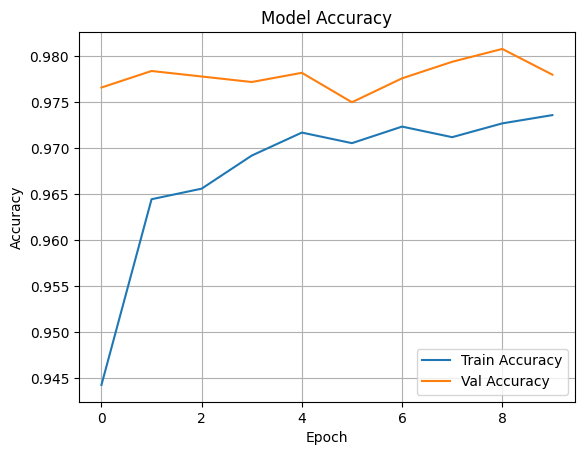

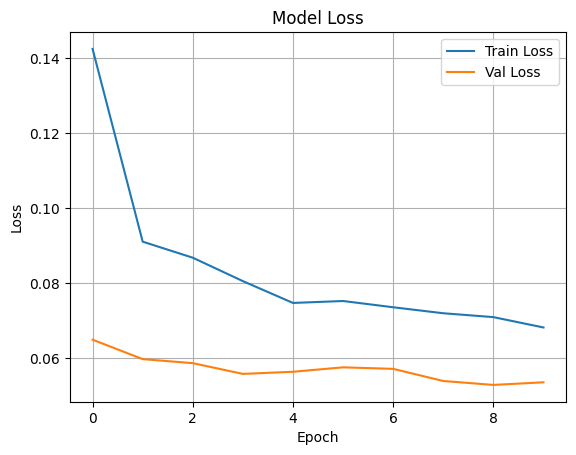

In [21]:
# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [22]:
model.save("mobilenetv2_cat_dog_model.h5")


In [26]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load your model
model = load_model("mobilenetv2_cat_dog_model.h5")

IMG_SIZE = 224  # Same as training

def predict_uploaded_image(file_path):
    # Load and preprocess image
    img = image.load_img(file_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)[0][0]

    # Show result
    plt.imshow(img)
    plt.axis('off')
    plt.title("Prediction: 🐶 Dog" if prediction > 0.5 else "Prediction: 🐱 Cat")
    plt.show()

    print(f"Confidence: {prediction:.4f} → {'Dog 🐶' if prediction > 0.5 else 'Cat 🐱'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


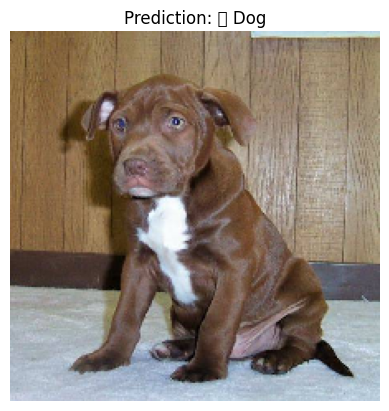

Confidence: 0.9996 → Dog 🐶


In [28]:
predict_uploaded_image("/content/test1/10139.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


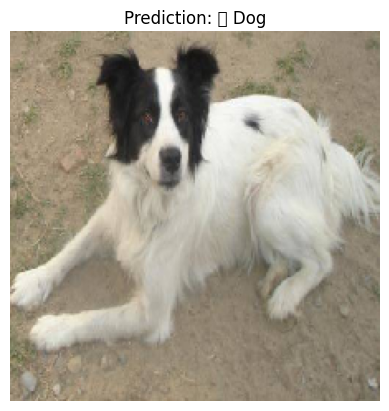

Confidence: 0.9994 → Dog 🐶


In [29]:
predict_uploaded_image("/content/test1/10181.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


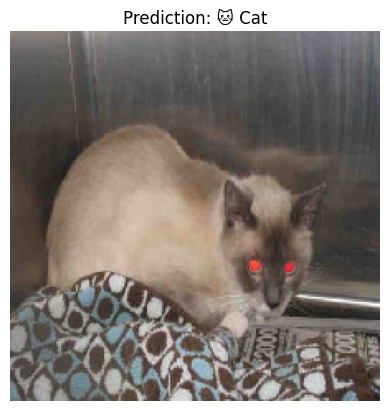

Confidence: 0.0009 → Cat 🐱


In [30]:
predict_uploaded_image("/content/test1/10604.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


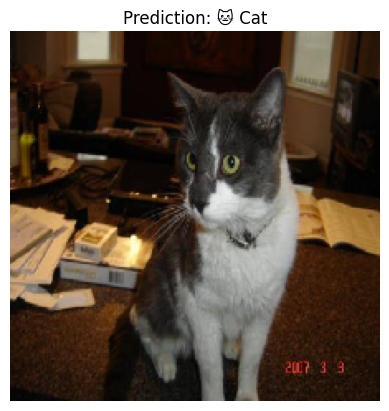

Confidence: 0.0003 → Cat 🐱


In [31]:
predict_uploaded_image("/content/test1/10539.jpg")